# 🐧 MLOps Penguins — Experimentación con MLflow

Este notebook implementa el flujo completo de MLOps:
1. **Carga de datos crudos** → PostgreSQL (`penguins_raw`)
2. **Preprocesamiento** → PostgreSQL (`penguins_processed`)
3. **Experimentación** → 20+ runs registrados en MLflow
4. **Registro del mejor modelo** → MLflow Model Registry

**Variables de entorno requeridas** (inyectadas por Docker Compose):
- `MLFLOW_TRACKING_URI` · `DB_HOST` · `DB_NAME` · `DB_USER` · `DB_PASSWORD`

---
## 0. Importaciones y configuración

In [1]:
import os
import warnings
import itertools
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sqlalchemy import create_engine, text
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    accuracy_score, f1_score, precision_score, recall_score,
    classification_report, confusion_matrix
)

import mlflow
import mlflow.sklearn
from mlflow.models.signature import infer_signature

warnings.filterwarnings('ignore')

# ── Configuración MLflow ─────────────────────────────────────
MLFLOW_URI = os.environ.get('MLFLOW_TRACKING_URI', 'http://mlflow:5000')
mlflow.set_tracking_uri(MLFLOW_URI)
EXPERIMENT_NAME = 'penguins-clasificacion'
mlflow.set_experiment(EXPERIMENT_NAME)

# ── Configuración PostgreSQL ─────────────────────────────────
DB_HOST = os.environ.get('DB_HOST', 'postgres')
DB_PORT = os.environ.get('DB_PORT', '5432')
DB_NAME = os.environ.get('DB_NAME', 'mlops_db')
DB_USER = os.environ.get('DB_USER', 'mlops')
DB_PASS = os.environ.get('DB_PASSWORD', 'mlops_secret')

DB_URL = f'postgresql://{DB_USER}:{DB_PASS}@{DB_HOST}:{DB_PORT}/{DB_NAME}'
engine = create_engine(DB_URL)

print(f'✅ MLflow URI   : {MLFLOW_URI}')
print(f'✅ PostgreSQL   : {DB_HOST}:{DB_PORT}/{DB_NAME}')
print(f'✅ Experimento  : {EXPERIMENT_NAME}')

2026/03/25 21:19:19 INFO mlflow.tracking.fluent: Experiment with name 'penguins-clasificacion' does not exist. Creating a new experiment.


✅ MLflow URI   : http://mlflow:5001
✅ PostgreSQL   : postgres:5432/mlops_db
✅ Experimento  : penguins-clasificacion


---
## 1. Carga de datos crudos → PostgreSQL

In [2]:
# Leer CSV
df_raw = pd.read_csv('/work/data/penguins.csv', index_col=0)
print(f'Filas originales: {len(df_raw)}')
display(df_raw.head())
display(df_raw.describe())

Filas originales: 344


,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex,year
1,Adelie,Torgersen,39.1,18.7,181.0,3750.0,male,2007
2,Adelie,Torgersen,39.5,17.4,186.0,3800.0,female,2007
3,Adelie,Torgersen,40.3,18.0,195.0,3250.0,female,2007
4,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN,2007
5,Adelie,Torgersen,36.7,19.3,193.0,3450.0,female,2007


,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,year
count,342.000000,342.000000,342.000000,342.000000,344.000000
mean,43.921930,17.151170,200.915205,4201.754386,2008.029070
std,5.459584,1.974793,14.061714,801.954536,0.818356
min,32.100000,13.100000,172.000000,2700.000000,2007.000000
25%,39.225000,15.600000,190.000000,3550.000000,2007.000000
50%,44.450000,17.300000,197.000000,4050.000000,2008.000000
75%,48.500000,18.700000,213.000000,4750.000000,2009.000000
max,59.600000,21.500000,231.000000,6300.000000,2009.000000


In [3]:
# Guardar datos crudos en PostgreSQL
df_raw.to_sql(
    'penguins_raw',
    engine,
    if_exists='replace',
    index=False,
    method='multi'
)

with engine.connect() as conn:
    count = conn.execute(text('SELECT COUNT(*) FROM penguins_raw')).scalar()
print(f'✅ penguins_raw: {count} filas insertadas en PostgreSQL')

✅ penguins_raw: 344 filas insertadas en PostgreSQL


---
## 2. Exploración de Datos (EDA)

In [4]:
# Leer desde PostgreSQL
with engine.connect() as conn:
    df = pd.read_sql('SELECT * FROM penguins_raw', conn)

print('Distribución de especies:')
print(df['species'].value_counts())
print(f'\nValores nulos:\n{df.isnull().sum()}')

Distribución de especies:
species
Adelie       152
Gentoo       124
Chinstrap     68
Name: count, dtype: int64

Valores nulos:
species               0
island                0
bill_length_mm        2
bill_depth_mm         2
flipper_length_mm     2
body_mass_g           2
sex                  11
year                  0
dtype: int64


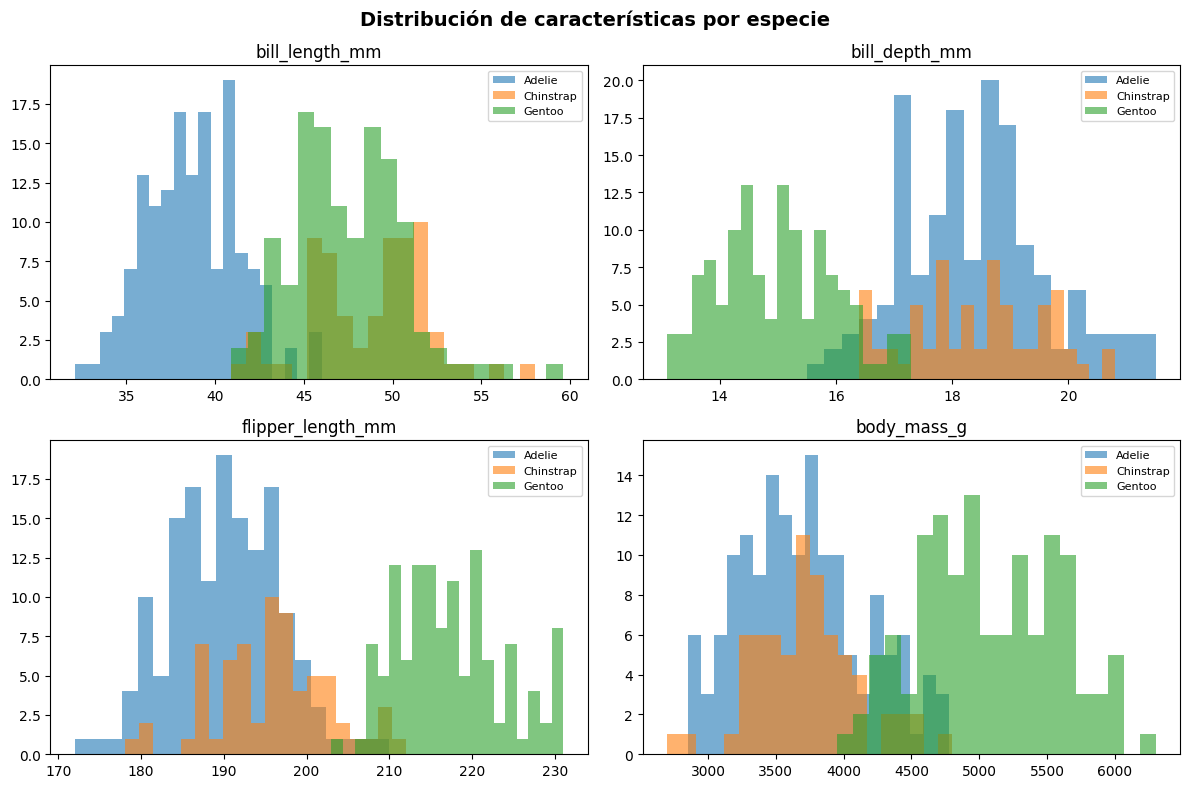

✅ Gráfico guardado


In [5]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
fig.suptitle('Distribución de características por especie', fontsize=14, fontweight='bold')

features = ['bill_length_mm', 'bill_depth_mm', 'flipper_length_mm', 'body_mass_g']
for ax, feat in zip(axes.flat, features):
    for species, grp in df.groupby('species'):
        ax.hist(grp[feat].dropna(), alpha=0.6, label=species, bins=20)
    ax.set_title(feat)
    ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig('/work/notebooks/eda_distribuciones.png', dpi=120, bbox_inches='tight')
plt.show()
print('✅ Gráfico guardado')

---
## 3. Preprocesamiento → penguins_processed

In [6]:
def preprocess(df_raw: pd.DataFrame) -> pd.DataFrame:
    """Limpieza, encoding y split train/test."""
    df = df_raw.copy()

    # 1. Eliminar filas con nulls en features numéricas
    num_cols = ['bill_length_mm', 'bill_depth_mm', 'flipper_length_mm', 'body_mass_g']
    df = df.dropna(subset=num_cols + ['species'])

    # 2. Imputar sex con moda
    df['sex'] = df['sex'].fillna(df['sex'].mode()[0])

    # 3. One-Hot Encoding manual (island, sex)
    df['island_Dream']     = (df['island'] == 'Dream').astype(int)
    df['island_Torgersen'] = (df['island'] == 'Torgersen').astype(int)
    # Biscoe es la categoría base
    df['sex_male'] = (df['sex'].str.lower() == 'male').astype(int)

    # 4. Codificar target
    le = LabelEncoder()
    df['species_label'] = df['species']
    df['species'] = le.fit_transform(df['species'])
    # Adelie=0, Chinstrap=1, Gentoo=2
    print('Clases:', dict(zip(le.classes_, le.transform(le.classes_))))

    # 5. Seleccionar columnas finales
    FEATURE_COLS = num_cols + ['island_Dream', 'island_Torgersen', 'sex_male']
    proc = df[FEATURE_COLS + ['species', 'species_label']].copy()

    # 6. Train/test split estratificado
    train_idx, test_idx = train_test_split(
        proc.index, test_size=0.2, random_state=42,
        stratify=proc['species']
    )
    proc['split'] = 'train'
    proc.loc[test_idx, 'split'] = 'test'

    return proc


df_proc = preprocess(df)
print(f'\nForma procesada: {df_proc.shape}')
print(df_proc['split'].value_counts())
display(df_proc.head())

Clases: {'Adelie': 0, 'Chinstrap': 1, 'Gentoo': 2}

Forma procesada: (342, 10)
split
train    273
test      69
Name: count, dtype: int64


,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,island_Dream,island_Torgersen,sex_male,species,species_label,split
0,39.1,18.7,181.0,3750.0,0,1,1,0,Adelie,train
1,39.5,17.4,186.0,3800.0,0,1,0,0,Adelie,test
2,40.3,18.0,195.0,3250.0,0,1,0,0,Adelie,train
4,36.7,19.3,193.0,3450.0,0,1,0,0,Adelie,train
5,39.3,20.6,190.0,3650.0,0,1,1,0,Adelie,train


In [7]:
# Guardar datos procesados en PostgreSQL
df_proc.to_sql(
    'penguins_processed',
    engine,
    if_exists='replace',
    index=False,
    method='multi'
)

with engine.connect() as conn:
    count = conn.execute(text('SELECT COUNT(*) FROM penguins_processed')).scalar()
print(f'✅ penguins_processed: {count} filas insertadas en PostgreSQL')

✅ penguins_processed: 342 filas insertadas en PostgreSQL


---
## 4. Preparar sets de entrenamiento desde PostgreSQL

In [8]:
FEATURE_COLS = [
    'bill_length_mm', 'bill_depth_mm', 'flipper_length_mm', 'body_mass_g',
    'island_Dream', 'island_Torgersen', 'sex_male'
]
TARGET = 'species'
LABEL_MAP = {0: 'Adelie', 1: 'Chinstrap', 2: 'Gentoo'}

with engine.connect() as conn:
    train_df = pd.read_sql(
        "SELECT * FROM penguins_processed WHERE split = 'train'", conn
    )
    test_df = pd.read_sql(
        "SELECT * FROM penguins_processed WHERE split = 'test'", conn
    )

X_train = train_df[FEATURE_COLS].values
y_train = train_df[TARGET].values
X_test  = test_df[FEATURE_COLS].values
y_test  = test_df[TARGET].values

print(f'Train: {X_train.shape} | Test: {X_test.shape}')
print(f'Clases train: {np.bincount(y_train)}')

Train: (273, 7) | Test: (69, 7)
Clases train: [121  54  98]


---
## 5. Función genérica de entrenamiento con MLflow

In [9]:
def run_experiment(
    model_name: str,
    model,
    params: dict,
    X_tr, y_tr, X_te, y_te,
    feature_cols: list
) -> dict:
    """
    Entrena un pipeline (Scaler + modelo), registra en MLflow
    y retorna las métricas del run.
    """
    # Pipeline con escalado
    pipe = Pipeline([
        ('scaler', StandardScaler()),
        ('clf', model)
    ])

    with mlflow.start_run(run_name=f'{model_name}') as run:
        # --- Parámetros ---
        mlflow.log_param('model_type', model_name)
        for k, v in params.items():
            mlflow.log_param(k, v)
        mlflow.log_param('n_features', len(feature_cols))
        mlflow.log_param('train_size', len(X_tr))
        mlflow.log_param('test_size',  len(X_te))

        # --- Entrenamiento ---
        pipe.fit(X_tr, y_tr)

        # --- Cross-validation ---
        cv_scores = cross_val_score(pipe, X_tr, y_tr, cv=5, scoring='accuracy')
        mlflow.log_metric('cv_accuracy_mean', cv_scores.mean())
        mlflow.log_metric('cv_accuracy_std',  cv_scores.std())

        # --- Métricas en test ---
        y_pred = pipe.predict(X_te)
        acc  = accuracy_score(y_te, y_pred)
        f1   = f1_score(y_te, y_pred, average='weighted')
        prec = precision_score(y_te, y_pred, average='weighted')
        rec  = recall_score(y_te, y_pred, average='weighted')

        mlflow.log_metric('test_accuracy',  acc)
        mlflow.log_metric('test_f1',        f1)
        mlflow.log_metric('test_precision', prec)
        mlflow.log_metric('test_recall',    rec)

        # --- Matriz de confusión como artefacto ---
        cm = confusion_matrix(y_te, y_pred)
        fig, ax = plt.subplots(figsize=(5, 4))
        sns.heatmap(
            cm, annot=True, fmt='d', cmap='Blues', ax=ax,
            xticklabels=LABEL_MAP.values(),
            yticklabels=LABEL_MAP.values()
        )
        ax.set_title(f'{model_name} — Confusion Matrix\nAcc={acc:.3f} F1={f1:.3f}')
        fig.tight_layout()
        cm_path = f'/tmp/cm_{run.info.run_id[:8]}.png'
        fig.savefig(cm_path, dpi=100)
        plt.close(fig)
        mlflow.log_artifact(cm_path, artifact_path='confusion_matrix')

        # --- Registrar modelo ---
        signature = infer_signature(X_tr, pipe.predict(X_tr))
        mlflow.sklearn.log_model(
            pipe,
            artifact_path='model',
            signature=signature,
            input_example=X_tr[:3]
        )

        run_id = run.info.run_id

    result = {
        'run_id': run_id,
        'model': model_name,
        'params': params,
        'test_accuracy': acc,
        'test_f1': f1,
        'cv_mean': cv_scores.mean(),
        'cv_std': cv_scores.std()
    }
    print(f"  [{model_name:30s}] acc={acc:.4f}  f1={f1:.4f}  cv={cv_scores.mean():.4f}±{cv_scores.std():.4f}")
    return result

---
## 6. Experimentación — 20+ runs con variación de hiperparámetros

In [10]:
all_results = []

# ── 1. Random Forest (8 combinaciones) ───────────────────────
print('=== Random Forest ===')
for n_est, max_depth, min_samples in itertools.product(
    [50, 100, 200],
    [None, 5],
    [2]
):
    if len([x for x in all_results if x['model'].startswith('RF')]) >= 6:
        break
    params = dict(n_estimators=n_est, max_depth=max_depth, min_samples_split=min_samples)
    model  = RandomForestClassifier(random_state=42, **params)
    res    = run_experiment('RF', model, params, X_train, y_train, X_test, y_test, FEATURE_COLS)
    all_results.append(res)

print(f'Runs RF: {len([r for r in all_results if r["model"]=="RF"])}')

=== Random Forest ===


2026/03/25 21:19:37 INFO mlflow.tracking._tracking_service.client: 🏃 View run RF at: http://mlflow:5001/#/experiments/1/runs/459e0c9023d540509b41a2f7a9007de1.
2026/03/25 21:19:37 INFO mlflow.tracking._tracking_service.client: 🧪 View experiment at: http://mlflow:5001/#/experiments/1.


  [RF                            ] acc=1.0000  f1=1.0000  cv=0.9890±0.0090


2026/03/25 21:19:41 INFO mlflow.tracking._tracking_service.client: 🏃 View run RF at: http://mlflow:5001/#/experiments/1/runs/f6d78a049ca642fdb6f28953e57ebf1d.
2026/03/25 21:19:41 INFO mlflow.tracking._tracking_service.client: 🧪 View experiment at: http://mlflow:5001/#/experiments/1.


  [RF                            ] acc=1.0000  f1=1.0000  cv=0.9890±0.0090


...

  [RF                            ] acc=1.0000  f1=1.0000  cv=0.9890±0.0090


2026/03/25 21:19:56 INFO mlflow.tracking._tracking_service.client: 🏃 View run RF at: http://mlflow:5001/#/experiments/1/runs/9eb837ef1036440492ec21249a7f51e4.
2026/03/25 21:19:56 INFO mlflow.tracking._tracking_service.client: 🧪 View experiment at: http://mlflow:5001/#/experiments/1.


  [RF                            ] acc=1.0000  f1=1.0000  cv=0.9890±0.0090


2026/03/25 21:20:00 INFO mlflow.tracking._tracking_service.client: 🏃 View run RF at: http://mlflow:5001/#/experiments/1/runs/8cc6d6175628498083c4a67f3b0f4c4b.
2026/03/25 21:20:00 INFO mlflow.tracking._tracking_service.client: 🧪 View experiment at: http://mlflow:5001/#/experiments/1.


  [RF                            ] acc=1.0000  f1=1.0000  cv=0.9890±0.0090
Runs RF: 6


In [11]:
# ── 2. Gradient Boosting (6 combinaciones) ────────────────────
print('=== Gradient Boosting ===')
for lr, n_est in itertools.product(
    [0.05, 0.1, 0.2],
    [100, 200]
):
    params = dict(learning_rate=lr, n_estimators=n_est, max_depth=3)
    model  = GradientBoostingClassifier(random_state=42, **params)
    res    = run_experiment("GBM", model, params, X_train, y_train, X_test, y_test, FEATURE_COLS)
    all_results.append(res)


=== Gradient Boosting ===


2026/03/25 21:20:06 INFO mlflow.tracking._tracking_service.client: 🏃 View run GBM at: http://mlflow:5001/#/experiments/1/runs/722ff931a0494d49b64bf4af0d526e1b.
2026/03/25 21:20:06 INFO mlflow.tracking._tracking_service.client: 🧪 View experiment at: http://mlflow:5001/#/experiments/1.


  [GBM                           ] acc=1.0000  f1=1.0000  cv=0.9853±0.0073


2026/03/25 21:20:13 INFO mlflow.tracking._tracking_service.client: 🏃 View run GBM at: http://mlflow:5001/#/experiments/1/runs/580e76e96bb945a7871eafd86b158b32.
2026/03/25 21:20:13 INFO mlflow.tracking._tracking_service.client: 🧪 View experiment at: http://mlflow:5001/#/experiments/1.


  [GBM                           ] acc=1.0000  f1=1.0000  cv=0.9780±0.0137


...

  [GBM                           ] acc=1.0000  f1=1.0000  cv=0.9854±0.0136


2026/03/25 21:20:30 INFO mlflow.tracking._tracking_service.client: 🏃 View run GBM at: http://mlflow:5001/#/experiments/1/runs/502f6e81b6b740c39234043d37f364aa.
2026/03/25 21:20:30 INFO mlflow.tracking._tracking_service.client: 🧪 View experiment at: http://mlflow:5001/#/experiments/1.


  [GBM                           ] acc=1.0000  f1=1.0000  cv=0.9854±0.0136


2026/03/25 21:20:36 INFO mlflow.tracking._tracking_service.client: 🏃 View run GBM at: http://mlflow:5001/#/experiments/1/runs/d1d1dd36d61341c283d8865d709c8e2b.
2026/03/25 21:20:36 INFO mlflow.tracking._tracking_service.client: 🧪 View experiment at: http://mlflow:5001/#/experiments/1.


  [GBM                           ] acc=1.0000  f1=1.0000  cv=0.9854±0.0136


In [12]:
# ── 3. Logistic Regression (4 combinaciones) ──────────────────
print('=== Logistic Regression ===')
for C, solver in itertools.product([0.1, 1.0, 10.0], ['lbfgs']):
    params = dict(C=C, solver=solver, max_iter=500)
    model  = LogisticRegression(multi_class='multinomial', random_state=42, **params)
    res    = run_experiment('LR', model, params, X_train, y_train, X_test, y_test, FEATURE_COLS)
    all_results.append(res)

=== Logistic Regression ===


2026/03/25 21:20:39 INFO mlflow.tracking._tracking_service.client: 🏃 View run LR at: http://mlflow:5001/#/experiments/1/runs/d1e8d4844ee64b21847b75b3cfb40cea.
2026/03/25 21:20:39 INFO mlflow.tracking._tracking_service.client: 🧪 View experiment at: http://mlflow:5001/#/experiments/1.


  [LR                            ] acc=1.0000  f1=1.0000  cv=0.9891±0.0145


2026/03/25 21:20:42 INFO mlflow.tracking._tracking_service.client: 🏃 View run LR at: http://mlflow:5001/#/experiments/1/runs/cc7a7edfc2dd438d8d10670a40761003.
2026/03/25 21:20:42 INFO mlflow.tracking._tracking_service.client: 🧪 View experiment at: http://mlflow:5001/#/experiments/1.


  [LR                            ] acc=1.0000  f1=1.0000  cv=0.9927±0.0089


2026/03/25 21:20:46 INFO mlflow.tracking._tracking_service.client: 🏃 View run LR at: http://mlflow:5001/#/experiments/1/runs/05b7c1d5de434d448aab89d052af6d9c.
2026/03/25 21:20:46 INFO mlflow.tracking._tracking_service.client: 🧪 View experiment at: http://mlflow:5001/#/experiments/1.


  [LR                            ] acc=1.0000  f1=1.0000  cv=0.9890±0.0090


In [13]:
# ── 4. SVM (4 combinaciones) ──────────────────────────────────
print('=== SVM ===')
for C, kernel in itertools.product([1.0, 10.0], ['rbf', 'poly']):
    params = dict(C=C, kernel=kernel)
    model  = SVC(probability=True, random_state=42, **params)
    res    = run_experiment('SVM', model, params, X_train, y_train, X_test, y_test, FEATURE_COLS)
    all_results.append(res)

=== SVM ===


2026/03/25 21:20:49 INFO mlflow.tracking._tracking_service.client: 🏃 View run SVM at: http://mlflow:5001/#/experiments/1/runs/b5936f2eb146484a999ef55043c8f4a5.
2026/03/25 21:20:49 INFO mlflow.tracking._tracking_service.client: 🧪 View experiment at: http://mlflow:5001/#/experiments/1.


  [SVM                           ] acc=1.0000  f1=1.0000  cv=0.9927±0.0089


2026/03/25 21:20:53 INFO mlflow.tracking._tracking_service.client: 🏃 View run SVM at: http://mlflow:5001/#/experiments/1/runs/c86824dfde60486c92a979498b32ad17.
2026/03/25 21:20:53 INFO mlflow.tracking._tracking_service.client: 🧪 View experiment at: http://mlflow:5001/#/experiments/1.


  [SVM                           ] acc=1.0000  f1=1.0000  cv=0.9927±0.0089


2026/03/25 21:20:57 INFO mlflow.tracking._tracking_service.client: 🏃 View run SVM at: http://mlflow:5001/#/experiments/1/runs/3c8d692897c24964a173064b8cf07c6a.
2026/03/25 21:20:57 INFO mlflow.tracking._tracking_service.client: 🧪 View experiment at: http://mlflow:5001/#/experiments/1.


  [SVM                           ] acc=1.0000  f1=1.0000  cv=0.9854±0.0136


2026/03/25 21:21:00 INFO mlflow.tracking._tracking_service.client: 🏃 View run SVM at: http://mlflow:5001/#/experiments/1/runs/f429467b1e8e45009db2fc753091835c.
2026/03/25 21:21:00 INFO mlflow.tracking._tracking_service.client: 🧪 View experiment at: http://mlflow:5001/#/experiments/1.


  [SVM                           ] acc=1.0000  f1=1.0000  cv=0.9890±0.0146


In [14]:
# ── 5. KNN (4 combinaciones) ──────────────────────────────────
print('=== KNN ===')
for n_neighbors, weights in itertools.product([3, 5, 7], ['uniform']):
    params = dict(n_neighbors=n_neighbors, weights=weights)
    model  = KNeighborsClassifier(**params)
    res    = run_experiment('KNN', model, params, X_train, y_train, X_test, y_test, FEATURE_COLS)
    all_results.append(res)

print(f'\n✅ Total de runs: {len(all_results)}')

=== KNN ===


2026/03/25 21:21:04 INFO mlflow.tracking._tracking_service.client: 🏃 View run KNN at: http://mlflow:5001/#/experiments/1/runs/fb0eecd9826649438acbcd0d122ebe58.
2026/03/25 21:21:04 INFO mlflow.tracking._tracking_service.client: 🧪 View experiment at: http://mlflow:5001/#/experiments/1.


  [KNN                           ] acc=1.0000  f1=1.0000  cv=0.9890±0.0090


2026/03/25 21:21:07 INFO mlflow.tracking._tracking_service.client: 🏃 View run KNN at: http://mlflow:5001/#/experiments/1/runs/6e42268862f74674b262e9090beaba00.
2026/03/25 21:21:07 INFO mlflow.tracking._tracking_service.client: 🧪 View experiment at: http://mlflow:5001/#/experiments/1.


  [KNN                           ] acc=1.0000  f1=1.0000  cv=0.9854±0.0136


2026/03/25 21:21:11 INFO mlflow.tracking._tracking_service.client: 🏃 View run KNN at: http://mlflow:5001/#/experiments/1/runs/16f41e6eba004150a61c3b194cee1ac2.
2026/03/25 21:21:11 INFO mlflow.tracking._tracking_service.client: 🧪 View experiment at: http://mlflow:5001/#/experiments/1.


  [KNN                           ] acc=1.0000  f1=1.0000  cv=0.9964±0.0073

✅ Total de runs: 22


---
## 7. Análisis de resultados

In [15]:
results_df = pd.DataFrame(all_results)
results_df = results_df.sort_values('test_accuracy', ascending=False).reset_index(drop=True)

print('=== TOP 10 modelos por accuracy ===')
display(results_df[['model', 'test_accuracy', 'test_f1', 'cv_mean', 'cv_std']].head(10))

=== TOP 10 modelos por accuracy ===


,model,test_accuracy,test_f1,cv_mean,cv_std
0,RF,1.0,1.0,0.989024,0.008963
1,RF,1.0,1.0,0.989024,0.008963
2,KNN,1.0,1.0,0.985387,0.013625
3,KNN,1.0,1.0,0.989024,0.008963
4,SVM,1.0,1.0,0.989024,0.014580
5,SVM,1.0,1.0,0.985387,0.013625
6,SVM,1.0,1.0,0.992727,0.008907
7,SVM,1.0,1.0,0.992727,0.008907
8,LR,1.0,1.0,0.989024,0.008963
9,LR,1.0,1.0,0.992727,0.008907


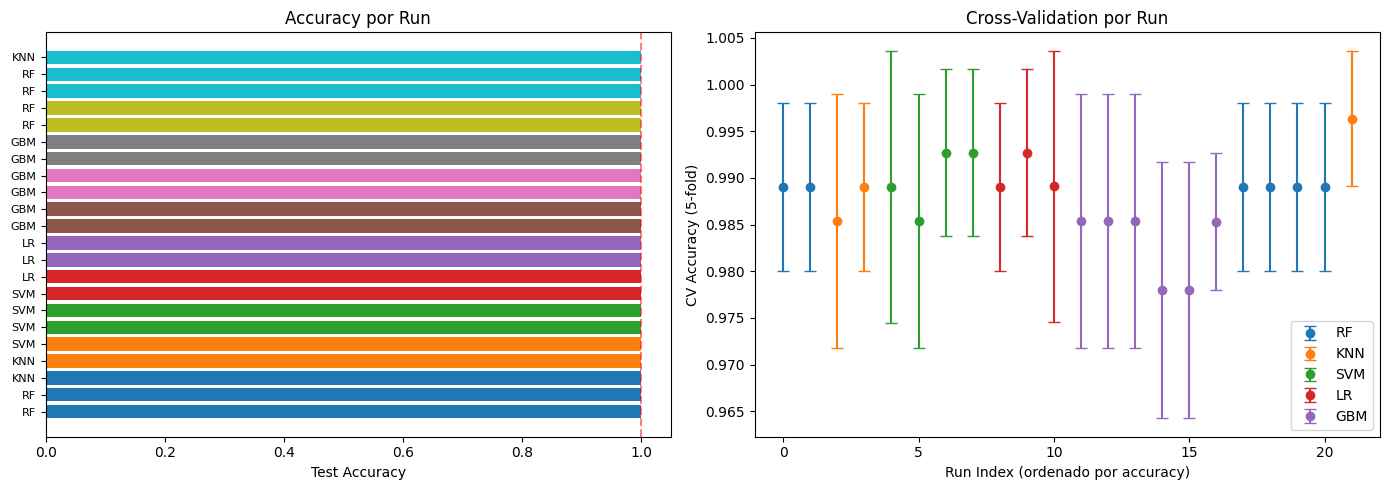

✅ Gráfico comparación guardado


In [16]:
# Gráfico de comparación
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Accuracy por modelo
colors = plt.cm.tab10(np.linspace(0, 1, len(results_df)))
bars = axes[0].barh(range(len(results_df)), results_df['test_accuracy'], color=colors)
axes[0].set_yticks(range(len(results_df)))
axes[0].set_yticklabels([f"{r['model']}" for _, r in results_df.iterrows()], fontsize=8)
axes[0].set_xlabel('Test Accuracy')
axes[0].set_title('Accuracy por Run')
axes[0].axvline(x=results_df['test_accuracy'].max(), color='red', linestyle='--', alpha=0.5)

# CV mean ± std por tipo de modelo
for model_type in results_df['model'].unique():
    sub = results_df[results_df['model'] == model_type]
    axes[1].errorbar(
        sub.index, sub['cv_mean'], yerr=sub['cv_std'],
        fmt='o', label=model_type, capsize=4
    )
axes[1].set_xlabel('Run Index (ordenado por accuracy)')
axes[1].set_ylabel('CV Accuracy (5-fold)')
axes[1].set_title('Cross-Validation por Run')
axes[1].legend()

plt.tight_layout()
plt.savefig('/work/notebooks/comparacion_runs.png', dpi=120, bbox_inches='tight')
plt.show()
print('✅ Gráfico comparación guardado')

---
## 8. Registrar el mejor modelo en MLflow Model Registry

In [17]:
best = results_df.iloc[0]
print(f'Mejor modelo: {best["model"]}')
print(f'  run_id      : {best["run_id"]}')
print(f'  test_accuracy: {best["test_accuracy"]:.4f}')
print(f'  test_f1      : {best["test_f1"]:.4f}')

# Registrar en Model Registry
MODEL_REGISTRY_NAME = 'penguins-classifier'
model_uri = f'runs:/{best["run_id"]}/model'

registered = mlflow.register_model(
    model_uri=model_uri,
    name=MODEL_REGISTRY_NAME
)

print(f'\n✅ Modelo registrado:')
print(f'   Nombre  : {registered.name}')
print(f'   Versión : {registered.version}')
print(f'   Run ID  : {best["run_id"]}')

Mejor modelo: RF
  run_id      : 459e0c9023d540509b41a2f7a9007de1
  test_accuracy: 1.0000
  test_f1      : 1.0000


Successfully registered model 'penguins-classifier'.
2026/03/25 21:21:12 INFO mlflow.store.model_registry.abstract_store: Waiting up to 300 seconds for model version to finish creation. Model name: penguins-classifier, version 1



✅ Modelo registrado:
   Nombre  : penguins-classifier
   Versión : 1
   Run ID  : 459e0c9023d540509b41a2f7a9007de1


Created version '1' of model 'penguins-classifier'.


In [18]:
# Transicionar a Production
from mlflow.tracking import MlflowClient

client = MlflowClient()
client.transition_model_version_stage(
    name=MODEL_REGISTRY_NAME,
    version=registered.version,
    stage='Production',
    archive_existing_versions=True
)

print(f'✅ Versión {registered.version} promovida a Production')

✅ Versión 1 promovida a Production


In [19]:
# Agregar descripción y tags al modelo
client.update_model_version(
    name=MODEL_REGISTRY_NAME,
    version=registered.version,
    description=f"""
    Modelo de clasificación de especies de pingüinos.
    Algoritmo : {best['model']}
    Accuracy  : {best['test_accuracy']:.4f}
    F1-score  : {best['test_f1']:.4f}
    CV mean   : {best['cv_mean']:.4f} ± {best['cv_std']:.4f}
    Dataset   : Palmer Penguins (344 registros, 7 features)
    Clases    : Adelie=0, Chinstrap=1, Gentoo=2
    """
)

client.set_model_version_tag(
    name=MODEL_REGISTRY_NAME,
    version=registered.version,
    key='framework',
    value='scikit-learn'
)
client.set_model_version_tag(
    name=MODEL_REGISTRY_NAME,
    version=registered.version,
    key='dataset',
    value='palmer-penguins'
)

print('✅ Metadata del modelo actualizada')

✅ Metadata del modelo actualizada


---
## 9. Validación: cargar modelo desde Registry y predecir

In [20]:
# Cargar el modelo en producción desde el registry
prod_model = mlflow.sklearn.load_model(
    model_uri=f'models:/{MODEL_REGISTRY_NAME}/Production'
)

# Predicción de ejemplo
sample = X_test[:5]
preds  = prod_model.predict(sample)
probas = prod_model.predict_proba(sample)

print('Predicciones de ejemplo (5 muestras):')
for i, (pred, proba) in enumerate(zip(preds, probas)):
    conf = proba.max()
    print(f"  [{i}] {LABEL_MAP[pred]:12s} (confianza={conf:.3f}) | real={LABEL_MAP[y_test[i]]}")

print(f'\n✅ Modelo cargado correctamente desde MLflow Registry')
print(f'   Accuracy en estas 5 muestras: {accuracy_score(y_test[:5], preds):.2f}')

Predicciones de ejemplo (5 muestras):
  [0] Adelie       (confianza=1.000) | real=Adelie
  [1] Adelie       (confianza=1.000) | real=Adelie
  [2] Adelie       (confianza=1.000) | real=Adelie
  [3] Adelie       (confianza=1.000) | real=Adelie
  [4] Adelie       (confianza=0.980) | real=Adelie

✅ Modelo cargado correctamente desde MLflow Registry
   Accuracy en estas 5 muestras: 1.00


---
## 10. Resumen final

In [21]:
print('=' * 60)
print('       RESUMEN DEL TALLER MLOps — Penguins')
print('=' * 60)
print(f'  Total de runs registrados en MLflow : {len(all_results)}')
print(f'  Modelos evaluados                   : {results_df["model"].nunique()}')
print(f'  Mejor modelo                        : {best["model"]}')
print(f'  Mejor accuracy (test)               : {best["test_accuracy"]:.4f}')
print(f'  Mejor F1-score (test)               : {best["test_f1"]:.4f}')
print(f'  Modelo en producción                : {MODEL_REGISTRY_NAME} v{registered.version}')
print()
print('  Accesos:')
print(f'    MLflow UI   → http://localhost:5001')
print(f'    MinIO UI    → http://localhost:9001')
print(f'    FastAPI     → http://localhost:8000/docs')
print('=' * 60)

       RESUMEN DEL TALLER MLOps — Penguins
  Total de runs registrados en MLflow : 22
  Modelos evaluados                   : 5
  Mejor modelo                        : RF
  Mejor accuracy (test)               : 1.0000
  Mejor F1-score (test)               : 1.0000
  Modelo en producción                : penguins-classifier v1

  Accesos:
    MLflow UI   → http://localhost:5001
    MinIO UI    → http://localhost:9001
    FastAPI     → http://localhost:8000/docs
